# DL Notebook 3 - Cross-modal transfer PZT -> LDV (supervised regression)

**Problem type:** *supervised regression / cross-modal mapping* - the teacher-student idea of the project.
**Question:** can a network predict the **LDV-virtual** per-path feature vector from the **PZT** per-path
feature vector? If yes, the modalities share learnable structure - the premise of Paper 2 (LDV->PZT
knowledge transfer).

**Data (Dataset 1):** `physics_features.npz` - `X_pzt_baseline` (30 paths x F) -> `X_ldv_virtual` (30 x F),
with `feature_names`. **Model:** a small MLP. **Evaluation:** leave-one-out CV (30 samples); report mean
R^2 and per-target R^2, against a linear-regression baseline.

> **Honest caveat:** 30 paired samples is tiny - this is a *feasibility* signal that cross-modal information
> is learnable, motivating the full distillation in Paper 2; it is not a trained transfer model.


In [1]:
# ===================== CONFIG =====================
FOLDER1 = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/260609_pzt_network"               # PZT network tensors + feature .npz
FOLDER2 = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/2606010_Innocore_STS304_6PZT"     # 12 LDV scans
SEED = 0
# =================================================
import os, glob, re
PROJECT_DIR = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK"
OUTPUT_DIR = os.path.join(PROJECT_DIR, "output")
MPLCONFIGDIR = os.path.join(PROJECT_DIR, ".matplotlib")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MPLCONFIGDIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", MPLCONFIGDIR)
def save_plot(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("saved:", path)
    return path
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import paper5_utils as u
np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
F1 = lambda n: os.path.join(FOLDER1, n)
print("torch", torch.__version__, "| device:", DEV)


torch 2.12.1 | device: cuda


dropping unusable all/mostly-missing features: ['dis_1mCC', 'dis_RMSD', 'dis_peak_shift_us']
remaining NaNs after dropping unusable features - Xp: 0 Xv: 2
paired samples: 30 | features: 7
MLP network input Xp: (30, 7) | PZT feature vector per path
MLP supervised target Xv: (30, 7) | LDV-virtual feature vector per path
saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_03_network_input_feature_matrices.png


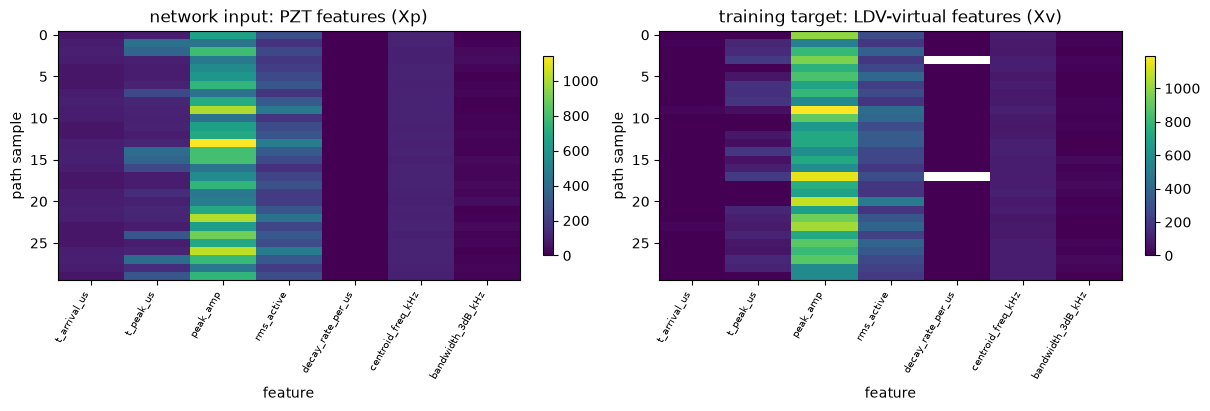

In [2]:
pf = np.load(F1("physics_features.npz"), allow_pickle=True)
Xp = np.atleast_2d(np.asarray(pf["X_pzt_baseline"], float))
Xv = np.atleast_2d(np.asarray(pf["X_ldv_virtual"], float))
names = [str(s) for s in np.asarray(pf["feature_names"]).ravel()] if "feature_names" in pf.files else None
if names is not None and Xp.shape[0] == len(names):    # orient to (paths, features)
    Xp, Xv = Xp.T, Xv.T
if names is None: names = [f"f{i}" for i in range(Xp.shape[1])]
finite_feature_mask = (np.isfinite(Xp).sum(axis=0) >= 2) & (np.isfinite(Xv).sum(axis=0) >= 2)
dropped = [names[i] for i in np.where(~finite_feature_mask)[0]]
if dropped:
    print("dropping unusable all/mostly-missing features:", dropped)
Xp = Xp[:, finite_feature_mask]
Xv = Xv[:, finite_feature_mask]
names = [names[i] for i in np.where(finite_feature_mask)[0]]
print("remaining NaNs after dropping unusable features - Xp:", int(np.isnan(Xp).sum()), "Xv:", int(np.isnan(Xv).sum()))
print("paired samples:", Xp.shape[0], "| features:", Xp.shape[1])
print("MLP network input Xp:", Xp.shape, "| PZT feature vector per path")
print("MLP supervised target Xv:", Xv.shape, "| LDV-virtual feature vector per path")
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
im0 = ax[0].imshow(Xp, aspect="auto", cmap="viridis")
ax[0].set(title="network input: PZT features (Xp)", xlabel="feature", ylabel="path sample")
im1 = ax[1].imshow(Xv, aspect="auto", cmap="viridis")
ax[1].set(title="training target: LDV-virtual features (Xv)", xlabel="feature", ylabel="path sample")
if len(names) <= 20:
    for axi in ax:
        axi.set_xticks(np.arange(len(names)))
        axi.set_xticklabels(names, rotation=60, ha="right", fontsize=7)
fig.colorbar(im0, ax=ax[0], shrink=0.8)
fig.colorbar(im1, ax=ax[1], shrink=0.8)
save_plot(fig, "DL_03_network_input_feature_matrices.png")
plt.show()

### 3.1 MLP + leave-one-out CV, vs a linear baseline

mean LOO R^2 - MLP: -2.670 | linear: -0.496
MLP network output pred_mlp: (30, 7) | predicted LDV-virtual feature vector per path
First predicted LDV feature vector: [ 4.66100e+00  1.07577e+02  9.26354e+02  3.85794e+02  3.00000e-03
  8.46290e+01 -1.67600e+00]
saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_03_network_output_prediction_matrix.png


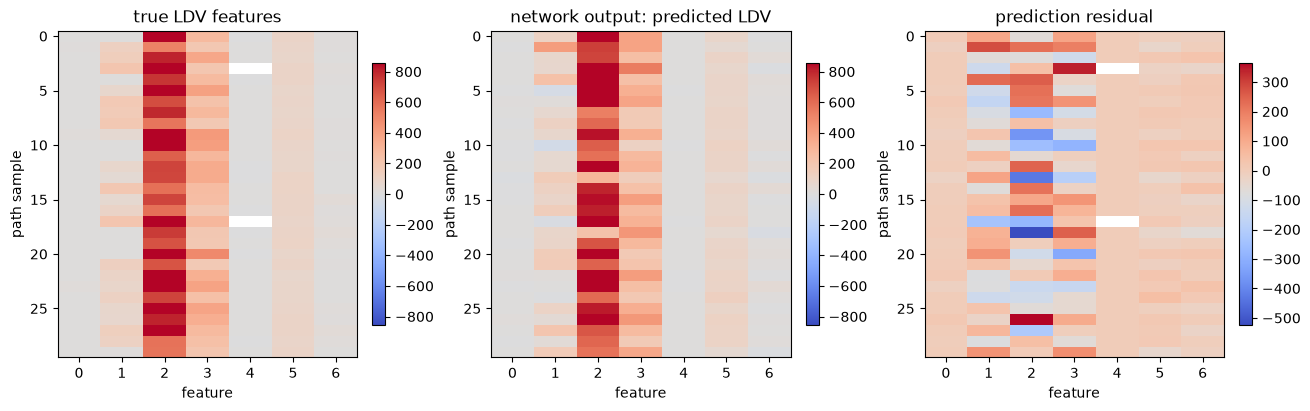

In [3]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

class MLP(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in,64), nn.ReLU(), nn.Linear(64,64), nn.ReLU(), nn.Linear(64,d_out))
    def forward(self, x): return self.net(x)

EPOCHS_MLP = 300
loo = LeaveOneOut()
pred_mlp = np.zeros_like(Xv); pred_lin = np.zeros_like(Xv)
for tr, te in loo.split(Xp):
    x_imp = SimpleImputer(strategy="median").fit(Xp[tr])
    y_imp = SimpleImputer(strategy="median").fit(Xv[tr])
    Xtr_raw = x_imp.transform(Xp[tr]); Xte_raw = x_imp.transform(Xp[te])
    Ytr_raw = y_imp.transform(Xv[tr])
    sx, sy = StandardScaler().fit(Xtr_raw), StandardScaler().fit(Ytr_raw)
    Xtr, Ytr = sx.transform(Xtr_raw), sy.transform(Ytr_raw); Xte = sx.transform(Xte_raw)
    # linear baseline
    pred_lin[te] = sy.inverse_transform(LinearRegression().fit(Xtr, Ytr).predict(Xte))
    # MLP
    net = MLP(Xtr.shape[1], Ytr.shape[1]).to(DEV); opt = torch.optim.Adam(net.parameters(), 5e-3, weight_decay=1e-3)
    lossf = nn.MSELoss(); xt = torch.tensor(Xtr, dtype=torch.float32).to(DEV); yt = torch.tensor(Ytr, dtype=torch.float32).to(DEV)
    net.train()
    for _ in range(EPOCHS_MLP):
        opt.zero_grad(); loss = lossf(net(xt), yt); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad():
        pred_mlp[te] = sy.inverse_transform(net(torch.tensor(Xte, dtype=torch.float32).to(DEV)).cpu().numpy())

def masked_r2(y_true, y_pred):
    vals = []
    for j in range(y_true.shape[1]):
        mask = np.isfinite(y_true[:, j]) & np.isfinite(y_pred[:, j])
        vals.append(r2_score(y_true[mask, j], y_pred[mask, j]) if mask.sum() >= 2 else np.nan)
    return np.array(vals)

r2_mlp = masked_r2(Xv, pred_mlp)
r2_lin = masked_r2(Xv, pred_lin)
print(f"mean LOO R^2 - MLP: {np.nanmean(r2_mlp):.3f} | linear: {np.nanmean(r2_lin):.3f}")
print("MLP network output pred_mlp:", pred_mlp.shape, "| predicted LDV-virtual feature vector per path")
print("First predicted LDV feature vector:", np.round(pred_mlp[0], 3))
v = np.nanpercentile(np.abs(np.concatenate([Xv.ravel(), pred_mlp.ravel()])), 95)
fig_out, axo = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
im0 = axo[0].imshow(Xv, aspect="auto", cmap="coolwarm", vmin=-v, vmax=v)
axo[0].set(title="true LDV features", xlabel="feature", ylabel="path sample")
im1 = axo[1].imshow(pred_mlp, aspect="auto", cmap="coolwarm", vmin=-v, vmax=v)
axo[1].set(title="network output: predicted LDV", xlabel="feature", ylabel="path sample")
im2 = axo[2].imshow(pred_mlp - Xv, aspect="auto", cmap="coolwarm")
axo[2].set(title="prediction residual", xlabel="feature", ylabel="path sample")
fig_out.colorbar(im0, ax=axo[0], shrink=0.8)
fig_out.colorbar(im1, ax=axo[1], shrink=0.8)
fig_out.colorbar(im2, ax=axo[2], shrink=0.8)
save_plot(fig_out, "DL_03_network_output_prediction_matrix.png")
plt.show()

### 3.2 Per-feature R^2 and a predicted-vs-true scatter

saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_03_cross_modal_transfer.png


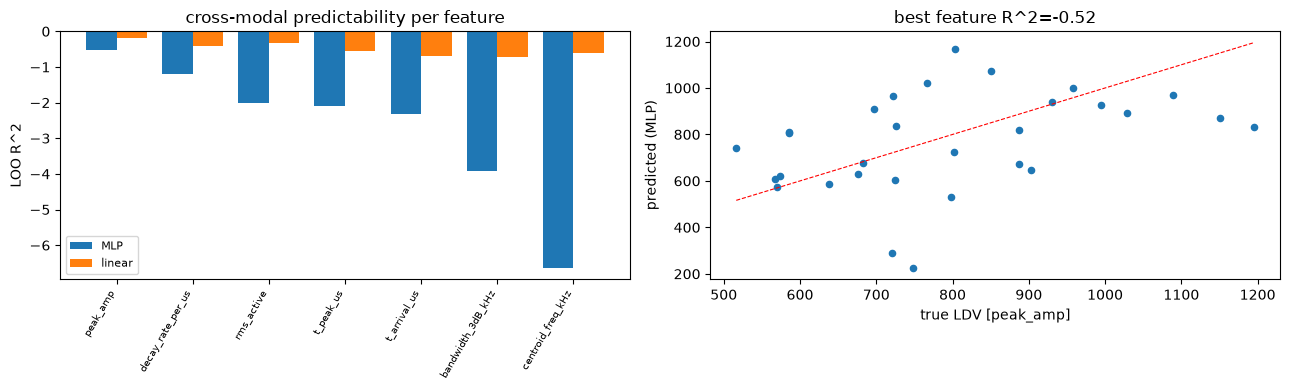

In [4]:
order = np.argsort(-r2_mlp)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(names)); w = 0.4
ax[0].bar(x-w/2, r2_mlp[order], w, label="MLP"); ax[0].bar(x+w/2, r2_lin[order], w, label="linear")
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_xticks(x); ax[0].set_xticklabels([names[i] for i in order], rotation=60, ha="right", fontsize=7)
ax[0].set(ylabel="LOO R^2", title="cross-modal predictability per feature"); ax[0].legend(fontsize=8)
k = order[0]
ax[1].scatter(Xv[:,k], pred_mlp[:,k], s=20); lim=[Xv[:,k].min(), Xv[:,k].max()]
ax[1].plot(lim, lim, "r--", lw=0.8); ax[1].set(xlabel=f"true LDV [{names[k]}]", ylabel="predicted (MLP)", title=f"best feature R^2={r2_mlp[k]:.2f}")
plt.tight_layout()
save_plot(fig, "DL_03_cross_modal_transfer.png")
plt.show()

### For the meeting
**Result line:** *"An MLP predicts LDV-virtual features from PZT features with mean leave-one-out R^2 = X
(linear baseline Y), evidence that the two modalities carry shared, learnable structure - the basis for
LDV->PZT knowledge transfer (Paper 2)."* Figure: per-feature R^2 bars + best-feature scatter. State the
30-sample caveat.